# Student Performance Analytics Using Hypothesis Testing
## BUSINESS PROBLEM
A school wants to understand:
What factors affect student performance the most?

## BUSINESS GOALS
- Do students who complete test prep score better?
- Does lunch type affect scores?
- Do male and female students perform differently?
- Which subject has highest variation?
- Which factors most influence performance?

In [2]:
!pip install scipy

   ---------------------------------------- 0.0/37.3 MB ? eta -:--:--
   ------ --------------------------------- 5.8/37.3 MB 33.2 MB/s eta 0:00:01
   --------- ------------------------------ 9.2/37.3 MB 24.5 MB/s eta 0:00:02
   ----------- ---------------------------- 10.7/37.3 MB 18.7 MB/s eta 0:00:02
   ----------- ---------------------------- 11.0/37.3 MB 14.9 MB/s eta 0:00:02
   ------------ --------------------------- 11.3/37.3 MB 11.1 MB/s eta 0:00:03
   ------------ --------------------------- 11.5/37.3 MB 9.4 MB/s eta 0:00:03
   ------------ --------------------------- 12.1/37.3 MB 8.3 MB/s eta 0:00:04
   ------------- -------------------------- 12.3/37.3 MB 8.0 MB/s eta 0:00:04
   ------------- -------------------------- 12.8/37.3 MB 6.7 MB/s eta 0:00:04
   -------------- ------------------------- 13.4/37.3 MB 6.3 MB/s eta 0:00:04
   -------------- ------------------------- 13.9/37.3 MB 6.0 MB/s eta 0:00:04
   --------------- ------------------------ 14.7/37.3 MB 5.8 MB/s eta


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: C:\Users\SENJUTI\AppData\Local\Python\pythoncore-3.14-64\python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

In [4]:
df = pd.read_csv("StudentsPerformance.csv")
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [6]:
df.shape

(1000, 8)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   gender                       1000 non-null   str  
 1   race/ethnicity               1000 non-null   str  
 2   parental level of education  1000 non-null   str  
 3   lunch                        1000 non-null   str  
 4   test preparation course      1000 non-null   str  
 5   math score                   1000 non-null   int64
 6   reading score                1000 non-null   int64
 7   writing score                1000 non-null   int64
dtypes: int64(3), str(5)
memory usage: 62.6 KB


In [8]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [9]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

In [10]:
df['average_score'] = (
    df['math score'] +
    df['reading score'] +
    df['writing score']
) / 3

In [12]:
df['average_score']

0      72.666667
1      82.333333
2      92.666667
3      49.333333
4      76.333333
         ...    
995    94.000000
996    57.333333
997    65.000000
998    74.333333
999    83.000000
Name: average_score, Length: 1000, dtype: float64

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


## Distribution of Math Scores

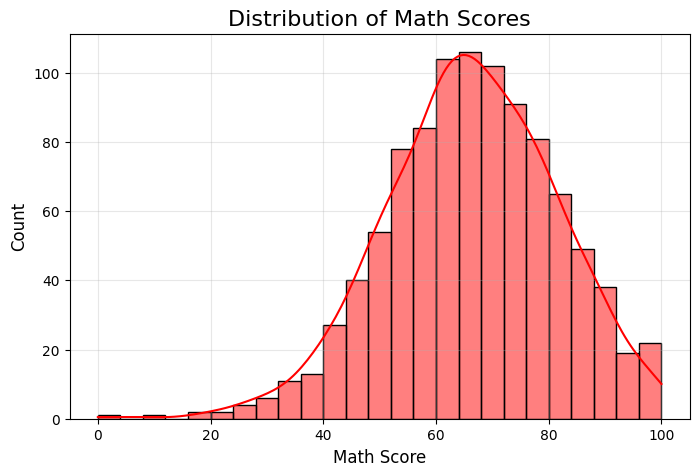

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['math score'],
    kde=True,
    color='red',         
    edgecolor='black'     
)

plt.title("Distribution of Math Scores", fontsize=16)
plt.xlabel("Math Score", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.grid(alpha=0.3)

plt.show()

## Compare Gender Performance

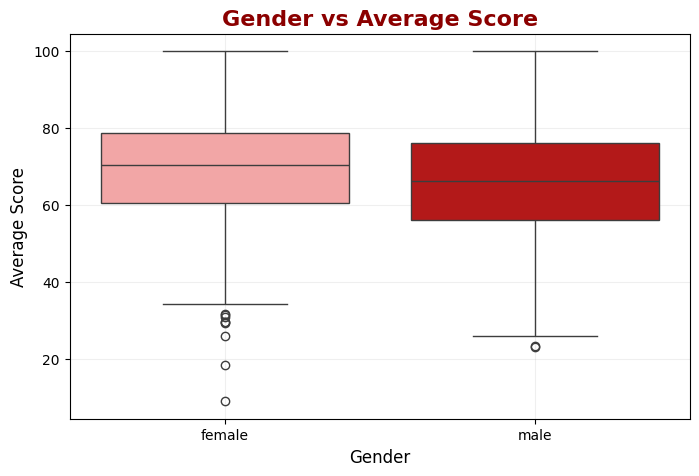

In [19]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='gender',
    y='average_score',
    hue='gender',
    data=df,
    palette=['#ff9999', '#cc0000'],
    legend=False
)

plt.title(
    "Gender vs Average Score",
    fontsize=16,
    fontweight='bold',
    color='darkred'
)

plt.xlabel("Gender", fontsize=12)
plt.ylabel("Average Score", fontsize=12)

plt.grid(alpha=0.2)

plt.show()

## Do male and female students have significantly different average scores?
Null Hypothesis - Male and female average scores are the same and 
Alternative Hypothesis - There is significant difference

In [32]:
male_scores = df[
    df['gender'] == 'male'
]['average_score']

female_scores = df[
    df['gender'] == 'female'
]['average_score']

In [33]:
from scipy import stats

t_stat, p_value = stats.ttest_ind(
    male_scores,
    female_scores
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: -4.169913529142
P-value: 3.31197363824367e-05


In [34]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


The t-test results indicate a statistically significant difference between male and female average scores.
## Correlation Analysis

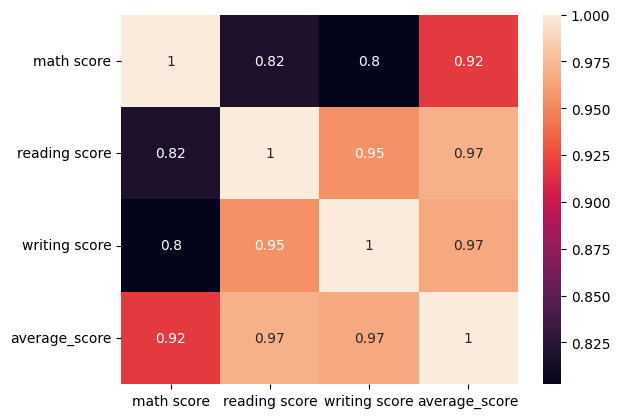

In [20]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True)

plt.show()

## Correlation Analysis
The heatmap reveals strong positive correlations among all subjects.
- Reading and writing scores show extremely high correlation (0.95), indicating students who perform well in reading also tend to perform well in writing.
- Math scores have slightly lower correlation with language-based subjects, suggesting mathematical ability may involve different learning patterns.
- Average scores are highly correlated with all subjects, especially reading and writing.

In [21]:
df.groupby('lunch')['average_score'].mean()

lunch
free/reduced    62.199061
standard        70.837209
Name: average_score, dtype: float64

## Does test preparation improve scores?
Null Hypothesis - No difference in scores
Alternative Hypothesis - Scores are different

In [25]:
completed = df[
    df['test preparation course'] == 'completed'
]['average_score']

none = df[
    df['test preparation course'] == 'none'
]['average_score']

In [26]:
t_stat, p_value = stats.ttest_ind(
    completed,
    none
)

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 8.390944443482592
P-value: 1.6337802035923472e-16


In [24]:
alpha = 0.05

if p_value < alpha:
    print("Reject Null Hypothesis")
else:
    print("Fail to Reject Null Hypothesis")

Reject Null Hypothesis


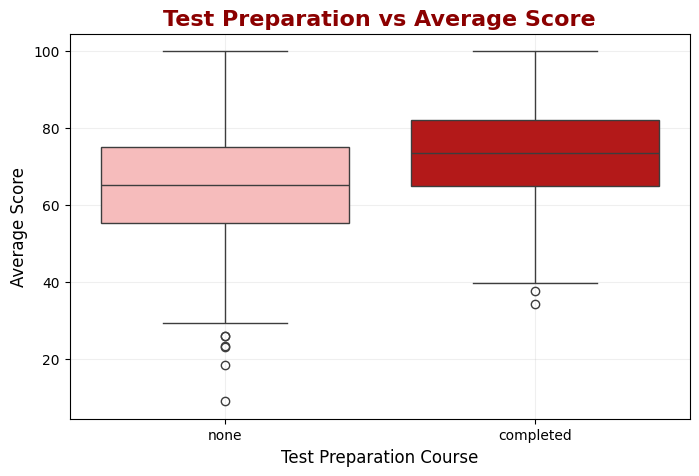

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='test preparation course',
    y='average_score',
    hue='test preparation course',
    data=df,
    palette=['#ffb3b3', '#cc0000'],
    legend=False
)

plt.title(
    "Test Preparation vs Average Score",
    fontsize=16,
    fontweight='bold',
    color='darkred'
)

plt.xlabel("Test Preparation Course", fontsize=12)
plt.ylabel("Average Score", fontsize=12)

plt.grid(alpha=0.2)

plt.show()

completed group scores higher: school should encourage preparation courses

## Analysize parent education

In [31]:
df.groupby(
    'parental level of education'
)['average_score'].mean().sort_values()

parental level of education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: average_score, dtype: float64

family educational background impacts student outcomes

## Top performers

In [35]:
df.sort_values(
    by='average_score',
    ascending=False
).head(10)

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,average_score
916,male,group E,bachelor's degree,standard,completed,100,100,100,100.000000
962,female,group E,associate's degree,standard,none,100,100,100,100.000000
458,female,group E,bachelor's degree,standard,none,100,100,100,100.000000
114,female,group E,bachelor's degree,standard,completed,99,100,100,99.666667
712,female,group D,some college,standard,none,98,100,99,99.000000
179,female,group D,some high school,standard,completed,97,100,100,99.000000
165,female,group C,bachelor's degree,standard,completed,96,100,100,98.666667
625,male,group D,some college,standard,completed,100,97,99,98.666667
685,female,group E,master's degree,standard,completed,94,99,100,97.666667
903,female,group D,bachelor's degree,free/reduced,completed,93,100,100,97.666667


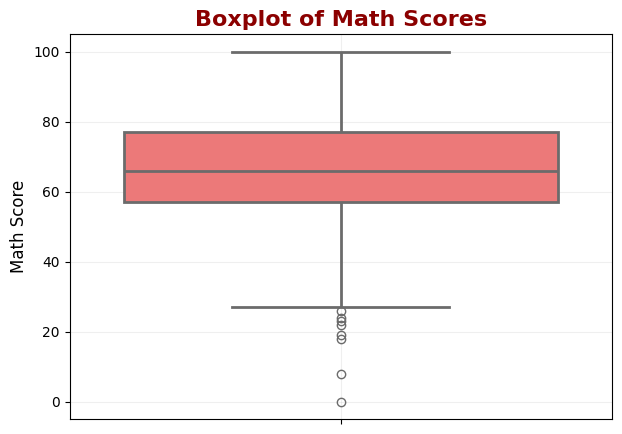

In [37]:
plt.figure(figsize=(7,5))

sns.boxplot(
    y=df['math score'],
    color='#ff6666',
    linewidth=2
)

plt.title(
    "Boxplot of Math Scores",
    fontsize=16,
    fontweight='bold',
    color='darkred'
)

plt.ylabel("Math Score", fontsize=12)

plt.grid(alpha=0.2)

plt.show()